<a href="https://colab.research.google.com/github/arulselvi-git/arulselvi-codebooster-2026/blob/main/Day2/day2project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported sucessfully")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")

All libraries imported sucessfully
pandas version:2.2.2
sqlite3 version:2.6.0


In [8]:
df=pd.read_csv("student_performance.csv")

In [9]:
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    index=False,
    if_exists='replace'
)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print("database 'college.db' created sucessfully")
print(f"Table 'students' has {count} rows")

database 'college.db' created sucessfully
Table 'students' has 30 rows


In [10]:
def run_query(sql, description="student"):
    if description:
        print(f"\n{'=' * 55}")
        print(f"{description}")
        print(f"{'=' * 55}")

    result = pd.read_sql_query(sql, conn)
    return result

print("Helper function 'run_query' defined successfully")
print("Usage: run_query(sql_string, description_label)")

Helper function 'run_query' defined successfully
Usage: run_query(sql_string, description_label)


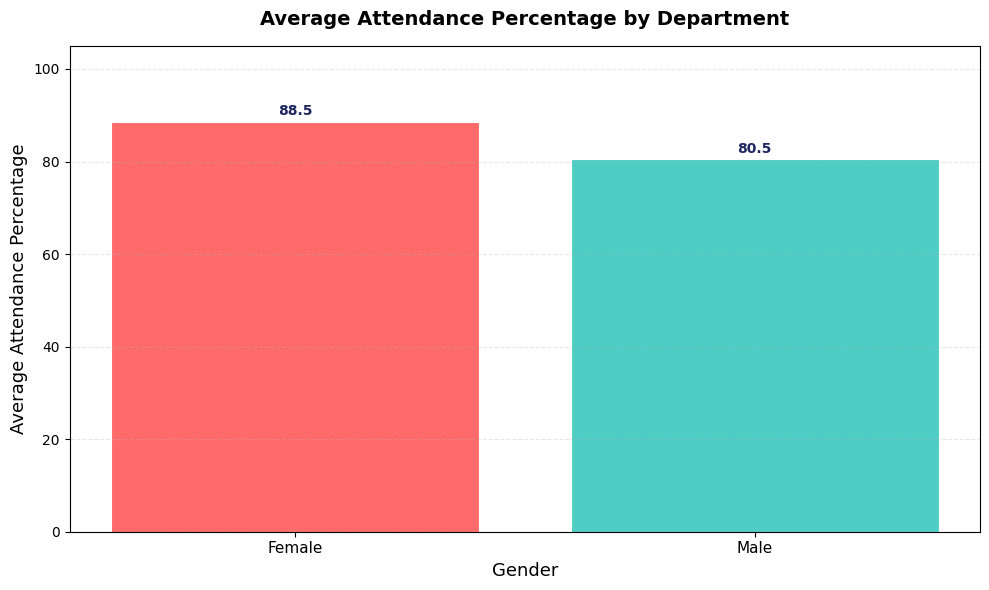

In [13]:
chart1_sql = """
SELECT gender, ROUND(AVG(attendance_percentage), 2) AS avg_attend
FROM students
GROUP BY gender
ORDER BY avg_attend DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#FF6B6B', '#4ECDC4']

bars = ax.bar(
    chart1_data['gender'],
    chart1_data['avg_attend'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#1E2761'
    )

ax.set_title(
    'Average Attendance Percentage by Department',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Gender', fontsize=13)
ax.set_ylabel('Average Attendance Percentage', fontsize=13)

ax.set_ylim(0, 105)

ax.tick_params(axis='x', labelsize=11)

ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

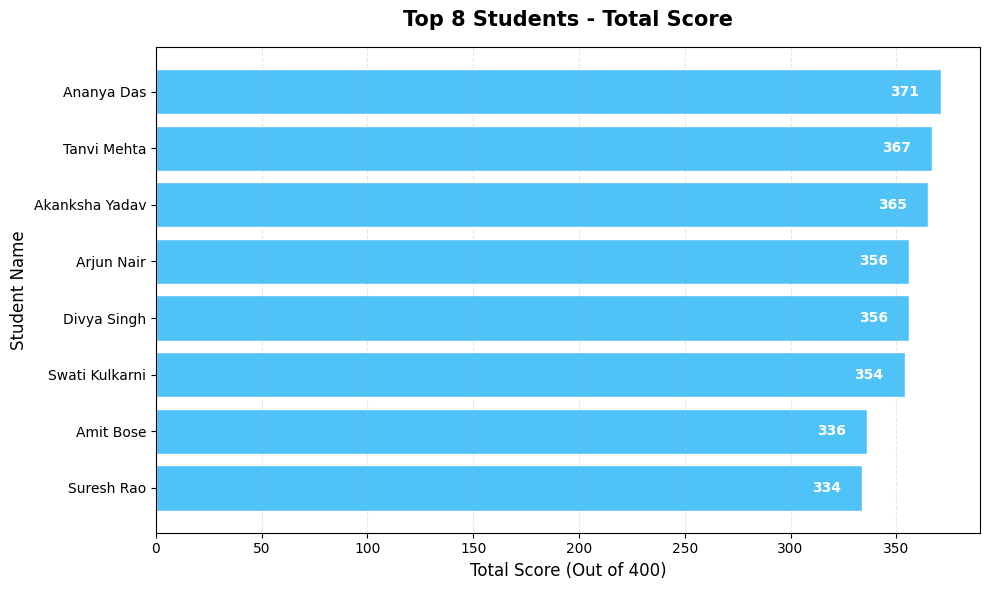

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# SQL Query
chart_sql = """
SELECT
    name,
    (math_score + science_score + programming_score + english_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

# Read data
chart_data = pd.read_sql_query(chart_sql, conn)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar chart
bars = ax.barh(
    chart_data['name'],
    chart_data['total_score'],
    color='#4FC3F7',
    edgecolor='white',
    linewidth=1
)

# Highest score on top
ax.invert_yaxis()

# Add score labels
for bar in bars:
    width = bar.get_width()

    ax.text(
        width - 10,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.0f}",
        va='center',
        ha='right',
        fontsize=10,
        fontweight='bold',
        color='white'
    )

# Title and labels
ax.set_title(
    'Top 8 Students - Total Score',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Total Score (Out of 400)', fontsize=12)
ax.set_ylabel('Student Name', fontsize=12)

# Grid
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

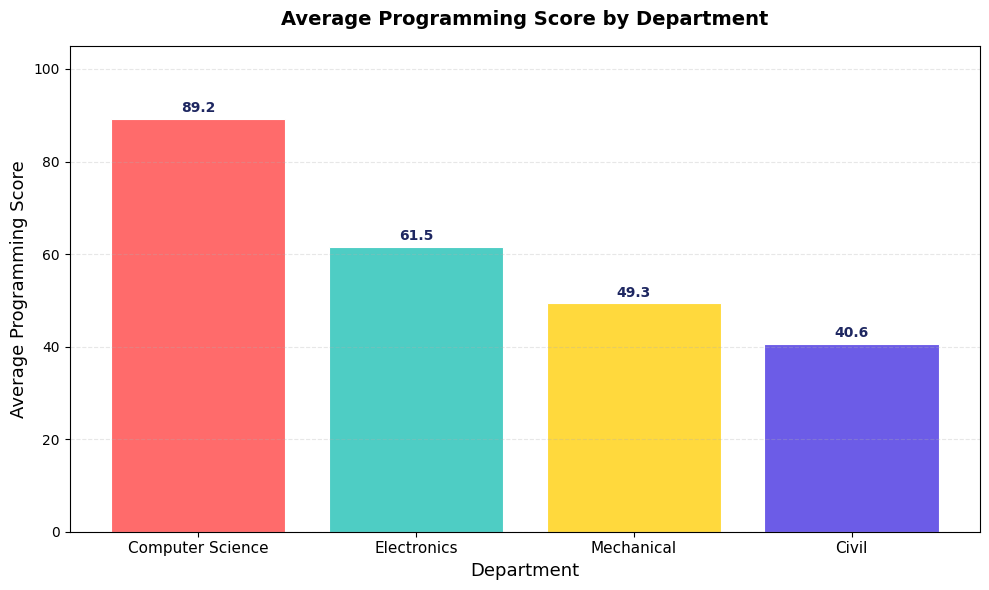

In [17]:
chart1_sql = """
SELECT department, ROUND(AVG(programming_score), 2) AS avg_programming
FROM students
GROUP BY department
ORDER BY avg_programming DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#FF6B6B', '#4ECDC4', '#FFD93D', '#6C5CE7']

bars = ax.bar(
    chart1_data['department'],
    chart1_data['avg_programming'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#1E2761'
    )

ax.set_title(
    'Average Programming Score by Department',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Programming Score', fontsize=13)

ax.set_ylim(0, 105)

ax.tick_params(axis='x', labelsize=11)

ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()